In [1]:
import parselmouth
import matplotlib.pyplot as plt
from audiochains.streams import StreamFromFile
from audiochains.block_methods import UnpackRawInFloat32
import numpy as np
import time as t  # Переименование модуля time

from kiwisolver import strength

In [28]:
import parselmouth
import matplotlib.pyplot as plt
from audiochains.streams import StreamFromFile
from audiochains.block_methods import UnpackRawInFloat32
import numpy as np
import time as t  # Переименование модуля time

def interpolate_nans(data):
    """
    Интерполяция пропущенных значений (NaN) в массиве данных.

    :param data: Массив данных с возможными NaN.
    :return: Массив данных без NaN.
    """
    nans = np.isnan(data)
    not_nans = ~nans  # Логическое отрицание для индексации не-NaN элементов

    indices = np.arange(len(data))  # Создаем массив индексов
    valid_indices = indices[not_nans]  # Индексы без NaN
    valid_values = data[not_nans]  # Значения без NaN

    if len(valid_indices) > 1:  # Проверяем, есть ли достаточно данных для интерполяции
        data[nans] = np.interp(indices[nans], valid_indices, valid_values)
    return data




def threshold_filter(data, max_jump=50):
    """
    Удаление резких скачков в данных частоты основного тона.

    :param data: Массив данных (частоты основного тона).
    :param max_jump: Максимальное допустимое изменение частоты между соседними точками.
    :return: Сглаженные данные.
    """
    filtered_data = data.copy()
    for i in range(1, len(data)):
        if not np.isnan(filtered_data[i]) and not np.isnan(filtered_data[i - 1]):
            if abs(filtered_data[i] - filtered_data[i - 1]) > max_jump:
                filtered_data[i] = filtered_data[i - 1]  # Сглаживаем скачок
    return filtered_data

def process_audio(
    audio_file,                  # Путь к аудиофайлу
    praat_file=None,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=75,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.03,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=512,               # Размер блока
    max_jump=50,                 # Максимальный скачок частоты для фильтрации
    plot_results=True            # Построить график
):
    """
    Функция для обработки аудио с использованием методов Parselmouth.
    """
    # Локальные переменные для результатов
    times = []
    frequencies = []
    praat_times = []
    praat_frequencies = []
    processing_times = []

    # Если указан файл Praat, читаем его данные
    if praat_file:
        try:
            with open(praat_file, 'r') as f:
                next(f)  # Пропускаем заголовок
                for line in f:
                    time, freq = line.strip().split()
                    time = float(time)
                    freq = float(freq) if freq != '--undefined--' else np.nan
                    praat_times.append(time)
                    praat_frequencies.append(freq)
        except Exception as e:
            print(f"Ошибка при чтении файла {praat_file}: {e}")

    # Обработка аудиофайла
    with StreamFromFile(
        filename=audio_file,
        blocksize=blocksize
    ) as stream:
        print(f"Частота дискретизации: {stream.samplerate} Гц")
        stream.set_methods(UnpackRawInFloat32())
        current_time = 0

        for i in range(stream.get_iterations()):
            try:
                raw_data = stream.read(blocksize)
                if not raw_data:
                    print(f"Блок {i} пустой, пропускаем...")
                    continue

                # Измеряем время начала обработки
                start_time = t.time()

                signal = stream.chain_of_methods(raw_data)
                sound = parselmouth.Sound(values=signal, sampling_frequency=stream.samplerate)

                # Выбор метода
                if method == "ac":
                    pitch = sound.to_pitch_ac(
                        time_step=time_step,
                        pitch_floor=pitch_floor,
                        pitch_ceiling=pitch_ceiling,
                        silence_threshold=silence_threshold,
                        voicing_threshold=voicing_threshold,
                        octave_cost=octave_cost,
                        octave_jump_cost=octave_jump_cost,
                        voiced_unvoiced_cost=voiced_unvoiced_cost
                    )
                elif method == "cc":
                    pitch = sound.to_pitch_cc(
                        time_step=time_step,
                        pitch_floor=pitch_floor,
                        pitch_ceiling=pitch_ceiling,
                        silence_threshold=silence_threshold,
                        voicing_threshold=voicing_threshold,
                        octave_cost=octave_cost,
                        octave_jump_cost=octave_jump_cost,
                        voiced_unvoiced_cost=voiced_unvoiced_cost
                    )
                else:
                    raise ValueError(f"Неизвестный метод: {method}. Используйте 'ac' или 'cc'.")

                frequency = pitch.selected_array['frequency']
                frequency[frequency == 0] = np.nan
                times.extend(current_time + pitch.xs())
                frequencies.extend(frequency)
                current_time += blocksize / stream.samplerate

                # Измеряем время окончания обработки и рассчитываем разницу
                end_time = t.time()
                processing_times.append(end_time - start_time)

            except Exception as err:
                print(f"Ошибка при обработке блока {i}: {err}")

    # Применяем фильтрацию для устранения резких скачков
    filtered_frequencies = threshold_filter(frequencies, max_jump=max_jump)

    # Вычисление среднего времени обработки одного блока
    if processing_times:
        avg_processing_time = sum(processing_times) / len(processing_times)
        print(f"Среднее время обработки одного блока ({blocksize} сэмплов): {avg_processing_time:.6f} секунд")
    else:
        print("Обработка не производилась, данные отсутствуют.")

    # Построение графика
    if plot_results and times and frequencies:
        plt.figure(figsize=(12, 8))

        # График для Parselmouth до фильтрации
        plt.plot(times, frequencies, label=f"Основной тон ({method}, до фильтрации)", color="blue", alpha=0.5)

        # График для Parselmouth после фильтрации
        plt.plot(times, filtered_frequencies, label=f"Основной тон ({method}, после фильтрации)", color="green")

        # График для файла Praat (если есть данные)
        if praat_times and praat_frequencies:
            plt.plot(praat_times, praat_frequencies, label="Основной тон (Praat)", color="red", linestyle="--")

        plt.xlabel("Время (с)")
        plt.ylabel("Частота (Гц)")
        plt.title("График основного тона")
        plt.legend()
        plt.grid()
        plt.show()
    else:
        print("Данные для построения графика отсутствуют.")

    # Возврат результатов
    return times, filtered_frequencies, praat_times, praat_frequencies


Частота дискретизации: 16000 Гц
Ошибка при обработке блока 301: To analyse this Sound, “minimum pitch” must not be less than 130.43478260869566 Hz.
Sound: pitch analysis not performed.
Среднее время обработки одного блока (512 сэмплов): 0.000094 секунд


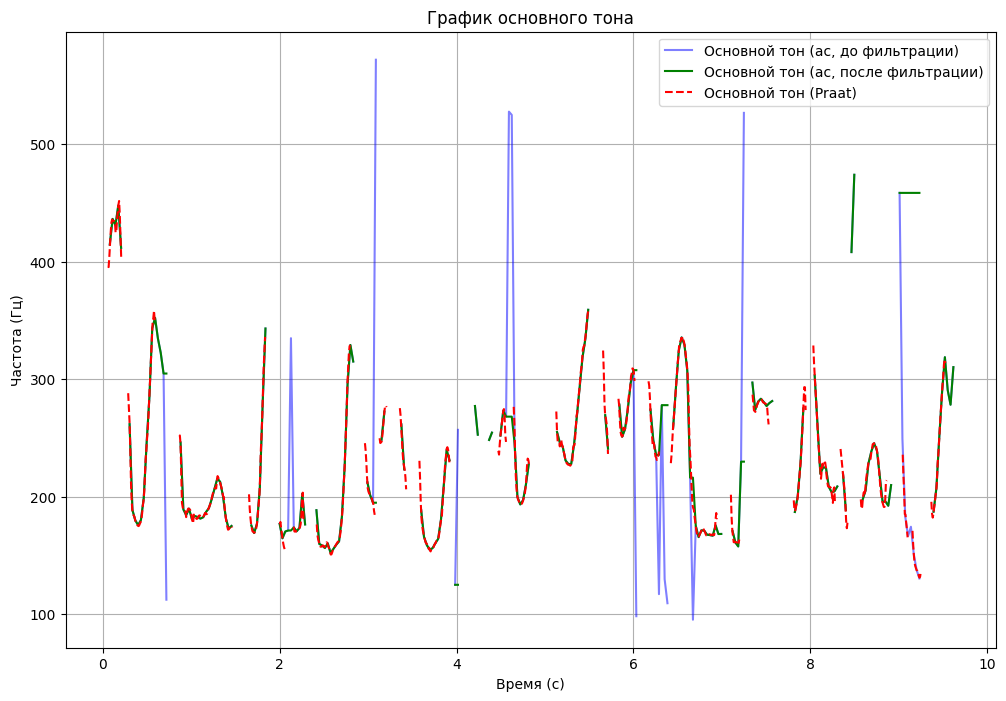

In [10]:

audio1 = 'silero_vad/files/femalechist2.wav' #женский голос без шумов
praat1 = 'silero_vad/files/praatfemalechist.txt' #женский голос без шумов
process_audio(
    audio1,                  # Путь к аудиофайлу
    praat_file=praat1,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=95,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.03,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=512,               # Размер блока
    max_jump=100,                 # Максимальный скачок частоты для фильтрации
    plot_results=True            # Построить график
);

In [14]:


def process_audio2(
    audio_file,                  # Путь к аудиофайлу
    praat_file=None,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=75,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.03,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=512,               # Размер блока
    max_jump=50,                 # Максимальный скачок частоты для фильтрации
    plot_results=True            # Построить график
):
    """
    Функция для обработки аудио с использованием методов Parselmouth.
    """
    # Локальные переменные для результатов
    times = []
    frequencies = []
    praat_times = []
    praat_frequencies = []
    processing_times = []

    # Если указан файл Praat, читаем его данные
    if praat_file:
        try:
            with open(praat_file, 'r') as f:
                next(f)  # Пропускаем заголовок
                for line in f:
                    time, freq = line.strip().split()
                    time = float(time)
                    freq = float(freq) if freq != '--undefined--' else np.nan
                    praat_times.append(time)
                    praat_frequencies.append(freq)
        except Exception as e:
            print(f"Ошибка при чтении файла {praat_file}: {e}")

    # Обработка аудиофайла
    with StreamFromFile(
        filename=audio_file,
        blocksize=blocksize
    ) as stream:
        print(f"Частота дискретизации: {stream.samplerate} Гц")
        stream.set_methods(UnpackRawInFloat32())
        current_time = 0

        for i in range(stream.get_iterations()):
            try:
                raw_data = stream.read(blocksize)
                if not raw_data:
                    print(f"Блок {i} пустой, пропускаем...")
                    continue

                # Измеряем время начала обработки
                start_time = t.time()

                signal = stream.chain_of_methods(raw_data)
                sound = parselmouth.Sound(values=signal, sampling_frequency=stream.samplerate)

                # Выбор метода
                if method == "ac":
                    pitch = sound.to_pitch_ac(
                        time_step=time_step,
                        pitch_floor=pitch_floor,
                        pitch_ceiling=pitch_ceiling,
                        silence_threshold=silence_threshold,
                        voicing_threshold=voicing_threshold,
                        octave_cost=octave_cost,
                        octave_jump_cost=octave_jump_cost,
                        voiced_unvoiced_cost=voiced_unvoiced_cost
                    )
                elif method == "cc":
                    pitch = sound.to_pitch_cc(
                        time_step=time_step,
                        pitch_floor=pitch_floor,
                        pitch_ceiling=pitch_ceiling,
                        silence_threshold=silence_threshold,
                        voicing_threshold=voicing_threshold,
                        octave_cost=octave_cost,
                        octave_jump_cost=octave_jump_cost,
                        voiced_unvoiced_cost=voiced_unvoiced_cost
                    )
                else:
                    raise ValueError(f"Неизвестный метод: {method}. Используйте 'ac' или 'cc'.")

                frequency = pitch.selected_array['frequency']
                frequency[frequency == 0] = np.nan
                times.extend(current_time + pitch.xs())
                frequencies.extend(frequency)
                current_time += blocksize / stream.samplerate

                # Измеряем время окончания обработки и рассчитываем разницу
                end_time = t.time()
                processing_times.append(end_time - start_time)

            except Exception as err:
                print(f"Ошибка при обработке блока {i}: {err}")

    # Применяем фильтрацию для устранения резких скачков
    filtered_frequencies = threshold_filter(frequencies, max_jump=max_jump)

    # Вычисление среднего времени обработки одного блока
    if processing_times:
        avg_processing_time = sum(processing_times) / len(processing_times)
        print(f"Среднее время обработки одного блока ({blocksize} сэмплов): {avg_processing_time:.6f} секунд")
    else:
        print("Обработка не производилась, данные отсутствуют.")

    # Построение графика
    if plot_results and times and frequencies:
        plt.figure(figsize=(12, 8))

        

        # График для Parselmouth после фильтрации
        plt.plot(times, filtered_frequencies, label=f"Основной тон ({method}, после фильтрации)", color="green")

        # График для файла Praat (если есть данные)
        if praat_times and praat_frequencies:
            plt.plot(praat_times, praat_frequencies, label="Основной тон (Praat)", color="red", linestyle="--")

        plt.xlabel("Время (с)")
        plt.ylabel("Частота (Гц)")
        plt.title("График основного тона")
        plt.legend()
        plt.grid()
        plt.show()
    else:
        print("Данные для построения графика отсутствуют.")

    # Возврат результатов
    return times, filtered_frequencies, praat_times, praat_frequencies


Частота дискретизации: 16000 Гц
Ошибка при обработке блока 301: To analyse this Sound, “minimum pitch” must not be less than 130.43478260869566 Hz.
Sound: pitch analysis not performed.
Среднее время обработки одного блока (512 сэмплов): 0.000107 секунд


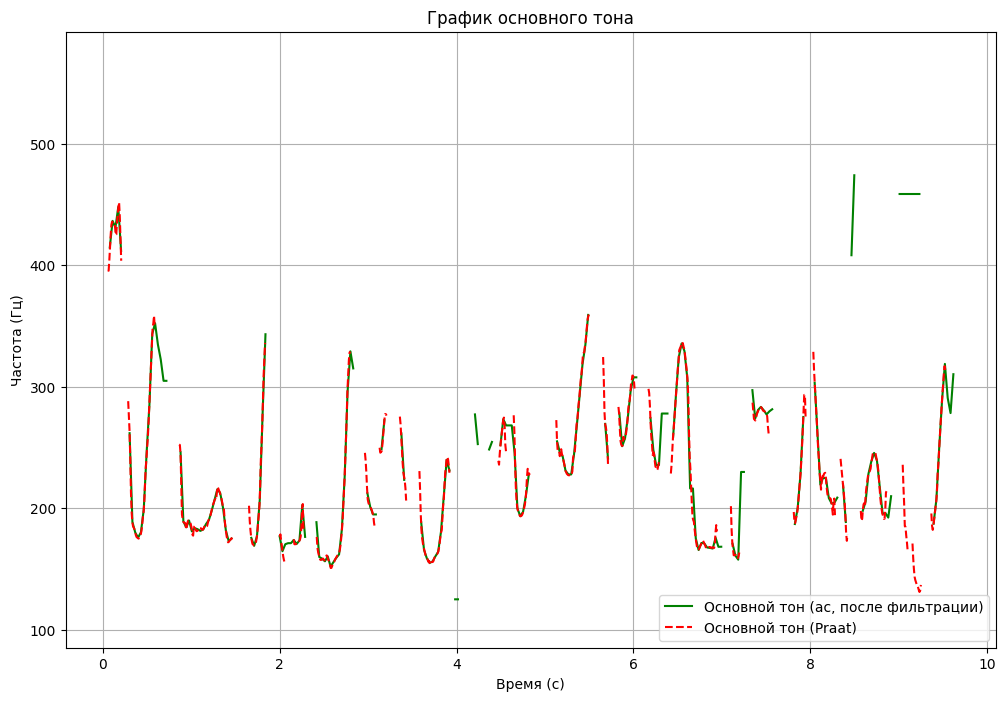

In [15]:

audio1 = 'silero_vad/files/femalechist2.wav' #женский голос без шумов
praat1 = 'silero_vad/files/praatfemalechist.txt' #женский голос без шумов
process_audio2(
    audio1,                  # Путь к аудиофайлу
    praat_file=praat1,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=95,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.03,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=512,               # Размер блока
    max_jump=100,                 # Максимальный скачок частоты для фильтрации
    plot_results=True            # Построить график
);

In [29]:

def process_audio_interpolate(
    audio_file,                  # Путь к аудиофайлу
    praat_file=None,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=75,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.03,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=512,               # Размер блока
    max_jump=50,                 # Максимальный скачок частоты для фильтрации
    plot_results=True            # Построить график
):
    """
    Функция для обработки аудио с использованием методов Parselmouth.
    """
    # Локальные переменные для результатов
    times = []
    frequencies = []
    praat_times = []
    praat_frequencies = []
    processing_times = []

    # Если указан файл Praat, читаем его данные
    if praat_file:
        try:
            with open(praat_file, 'r') as f:
                next(f)  # Пропускаем заголовок
                for line in f:
                    time, freq = line.strip().split()
                    time = float(time)
                    freq = float(freq) if freq != '--undefined--' else np.nan
                    praat_times.append(time)
                    praat_frequencies.append(freq)
        except Exception as e:
            print(f"Ошибка при чтении файла {praat_file}: {e}")

    # Обработка аудиофайла
    with StreamFromFile(
        filename=audio_file,
        blocksize=blocksize
    ) as stream:
        print(f"Частота дискретизации: {stream.samplerate} Гц")
        stream.set_methods(UnpackRawInFloat32())
        current_time = 0

        for i in range(stream.get_iterations()):
            try:
                raw_data = stream.read(blocksize)
                if not raw_data:
                    print(f"Блок {i} пустой, пропускаем...")
                    continue

                # Измеряем время начала обработки
                start_time = t.time()

                signal = stream.chain_of_methods(raw_data)
                sound = parselmouth.Sound(values=signal, sampling_frequency=stream.samplerate)

                # Выбор метода
                if method == "ac":
                    pitch = sound.to_pitch_ac(
                        time_step=time_step,
                        pitch_floor=pitch_floor,
                        pitch_ceiling=pitch_ceiling,
                        silence_threshold=silence_threshold,
                        voicing_threshold=voicing_threshold,
                        octave_cost=octave_cost,
                        octave_jump_cost=octave_jump_cost,
                        voiced_unvoiced_cost=voiced_unvoiced_cost
                    )
                elif method == "cc":
                    pitch = sound.to_pitch_cc(
                        time_step=time_step,
                        pitch_floor=pitch_floor,
                        pitch_ceiling=pitch_ceiling,
                        silence_threshold=silence_threshold,
                        voicing_threshold=voicing_threshold,
                        octave_cost=octave_cost,
                        octave_jump_cost=octave_jump_cost,
                        voiced_unvoiced_cost=voiced_unvoiced_cost
                    )
                else:
                    raise ValueError(f"Неизвестный метод: {method}. Используйте 'ac' или 'cc'.")

                frequency = pitch.selected_array['frequency']
                frequency[frequency == 0] = np.nan
                times.extend(current_time + pitch.xs())
                frequencies.extend(frequency)
                current_time += blocksize / stream.samplerate

                # Измеряем время окончания обработки и рассчитываем разницу
                end_time = t.time()
                processing_times.append(end_time - start_time)

            except Exception as err:
                print(f"Ошибка при обработке блока {i}: {err}")

    # Применяем фильтрацию для устранения резких скачков
    filtered_frequencies = threshold_filter(frequencies, max_jump=max_jump)

    # Интерполируем пропущенные значения для сплошного графика
    interpolated_frequencies = interpolate_nans(filtered_frequencies)

    # Вычисление среднего времени обработки одного блока
    if processing_times:
        avg_processing_time = sum(processing_times) / len(processing_times)
        print(f"Среднее время обработки одного блока ({blocksize} сэмплов): {avg_processing_time:.6f} секунд")
    else:
        print("Обработка не производилась, данные отсутствуют.")

    # Построение графика
    if plot_results and times and frequencies:
        plt.figure(figsize=(12, 8))

        # График для Parselmouth до фильтрации
        plt.plot(times, frequencies, label=f"Основной тон ({method}, до фильтрации)", color="blue", alpha=0.5)

        # График для Parselmouth после фильтрации
        plt.plot(times, filtered_frequencies, label=f"Основной тон ({method}, после фильтрации)", color="green", alpha=0.5)

        # График для Parselmouth после интерполяции
        plt.plot(times, interpolated_frequencies, label=f"Основной тон ({method}, интерполяция)", color="orange")

        # График для файла Praat (если есть данные)
        if praat_times and praat_frequencies:
            plt.plot(praat_times, praat_frequencies, label="Основной тон (Praat)", color="red", linestyle="--")

        plt.xlabel("Время (с)")
        plt.ylabel("Частота (Гц)")
        plt.title("График основного тона")
        plt.legend()
        plt.grid()
        plt.show()
    else:
        print("Данные для построения графика отсутствуют.")

    # Возврат результатов
    return times, interpolated_frequencies, praat_times, praat_frequencies


In [ ]:

audio1 = 'silero_vad/files/femalechist2.wav' #женский голос без шумов
praat1 = 'silero_vad/files/praatfemalechist.txt' #женский голос без шумов
process_audio_interpolate(
    audio1,                  # Путь к аудиофайлу
    praat_file=praat1,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=95,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.03,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=1024,               # Размер блока
    max_jump=100,                 # Максимальный скачок частоты для фильтрации
    plot_results=True            # Построить график
);